



## Introducción a la Programación Usando Modelos **Generativos**
<div style="border-style:groove;border-width:thin;padding:10px">

**Bibliografía:** Hands-On Generative AI with Transformers and Diffusion Models

#### Transformers y Modelos de Lenguaje, cómo funcionan por dentro
</div>

#### ¿Qué es un modelo causal (autoregresivo)?
<div style="border-style:groove;border-width:thin;padding:10px">

- Entrenado para **predecir el siguiente token** dada una secuencia previa
- Ejemplos: GPT-2, Qwen, SmolLM
- Generan texto repitiendo esta predicción una y otra vez

</div>

<div style="border-style:groove;border-width:thin;padding:10px">

Usaremos AutoTokenizer y AutoModelFor*. Para la clase de modelo automática, hay que especificar para qué tarea se usará el modelo, como clasificación (AutoModelForSequenceClassification) o detección de objetos (AutoModelForObjectDetection). En el caso de Qwen2, usaremos la clase correspondiente al modelado de lenguaje causal.
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
AutoTokenizer es una clase de la librería transformers que sirve para cargar automáticamente el tokenizador adecuado para un modelo dado, sin necesidad de conocer el nombre exacto de la clase del tokenizador.
Por ejemplo, en lugar de tener que escribir Qwen2Tokenizer explícitamente, simplemente usas AutoTokenizer y la librería se encarga de seleccionar la clase correcta según la configuración del modelo. En el caso de Qwen2, internamente usaría Qwen2Tokenizer.
</div>

In [2]:
from transformers import AutoTokenizer
# Usamos el modelo que queramos. Ejemplos:
# GPT-2 "openai-community/gpt2"
# Qwen "Qwen/Qwen2-0.5B"
# SmolLM "HuggingFaceTB/SmolLM-135M"
prompt = "It was a dark and stormy"
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2-0.5B")
input_ids = tokenizer(prompt).input_ids
input_ids
[2132, 572, 264, 6319, 323, 13458, 88]
for t in input_ids:
    print(t, "\t:", tokenizer.decode(t))

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

2132 	: It
572 	:  was
264 	:  a
6319 	:  dark
323 	:  and
13458 	:  storm
88 	: y


In [3]:
from transformers import AutoModelForCausalLM
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2-0.5B")

# Tokenizamos de nuevo, pero especificando cual queremos.
# devolvemos un PyTorch tensor, que es lo que esperea el modelo.
# Sino le pasaríamos una lista de enteros.
input_ids = tokenizer(prompt, return_tensors="pt").input_ids
outputs = model(input_ids)
outputs.logits.shape # An output for each input token

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

torch.Size([1, 7, 151936])

<div style="border-style:groove;border-width:thin;padding:10px">

Para cada token de la secuencia de entrada, el modelo genera ~150.000 números llamados logits, uno por cada token del vocabulario. Estos indican la probabilidad de que cada token sea una buena continuación de la secuencia hasta ese punto. Un logit más alto significa que el modelo considera ese token más probable como continuación.

</div>

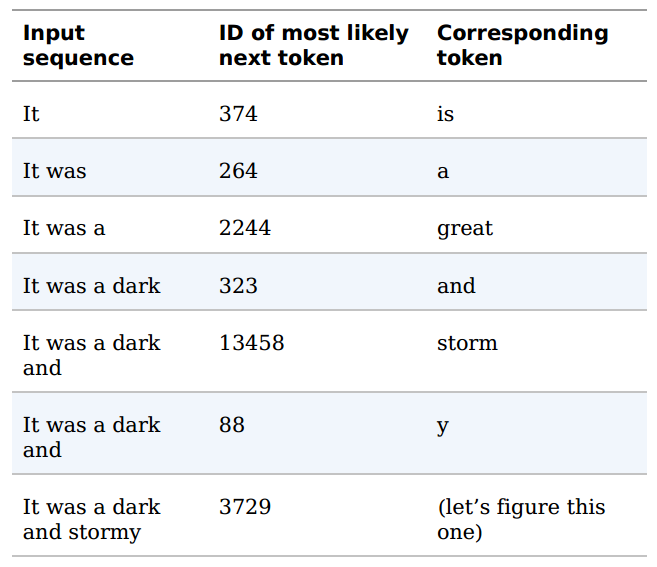

<div style="border-style:groove;border-width:thin;padding:10px">

Para predecir la siguiente palabra de la secuencia tenemos que ver la última predicción:

</div>

In [4]:

final_logits = model(input_ids).logits[0, -1] # La última lista de logits
final_logits.argmax() # Cogemos la posición que da el máximo.

tensor(3729)

<div style="border-style:groove;border-width:thin;padding:10px">

Decodificamos pasando de posición a palabra. Traducimos el token.

</div>

In [5]:
tokenizer.decode(final_logits.argmax())

' night'

<div style="border-style:groove;border-width:thin;padding:10px">

Para ver los top 10 tokens más adecuados para seguir la frase:

</div>

In [6]:
import torch
top10 = torch.topk(final_logits.softmax(dim=0), 10)
for value, index in zip(top10.values, top10.indices):
    print(f"{tokenizer.decode(index):<10} {value.item():.2%}")

 night     88.67%
 evening   4.42%
 day       2.22%
 morning   0.46%
 winter    0.44%
 afternoon 0.27%
 Saturday  0.25%
 Sunday    0.18%
 Friday    0.16%
 October   0.16%


<div style="border-style:groove;border-width:thin;padding:10px">

Viendo el resultado te puedes imaginar que la salida es de tipo softmax.

</div>

<div style="border-style:groove;border-width:thin;padding:10px">

Ahora ya sabemos como generar una palabra, solo tendríamos que volver a pedir una predicción al modelo usando el resultado como entrada en bucle y generamos un texto. model tiene el método generate() para eso.
</div>

In [7]:
output_ids = model.generate(input_ids, max_new_tokens=20)
decoded_text = tokenizer.decode(output_ids[0])
print("Input IDs", input_ids[0])
print("Output IDs", output_ids)
print(f"Generated text: {decoded_text}")

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Input IDs tensor([ 2132,   572,   264,  6319,   323, 13458,    88])
Output IDs tensor([[ 2132,   572,   264,  6319,   323, 13458,    88,  3729,    13,   576,
         12884,   572,  6319,   323,   279,  9956,   572,  1246,  2718,    13,
           576, 11174,   572, 50413,  1495,   323,   279]])
Generated text: It was a dark and stormy night. The sky was dark and the wind was howling. The rain was pouring down and the


<div style="border-style:groove;border-width:thin;padding:10px">

Una lista de logits para cada token del vocabulario (151.936). Luego había que calcular las probabilidades y elegir el token más probable. El método generate() abstrae toda esta lógica: predice el siguiente token repetidamente y lo va añadiendo a la secuencia de entrada.

</div>

#### Estrategias de generación de texto

| Estrategia | Descripción |
|---|---|
| **Greedy** | Elige el token más probable en cada paso |
| **Beam Search** | Explora varias continuaciones a la vez |
| **Sampling** | Muestrea de la distribución de probabilidad |
| **Top-K** | Solo considera los K tokens más probables |
| **Top-p (nucleus)** | Usa tokens cuya probabilidad acumulada supere p |

<div style="border-style:groove;border-width:thin;padding:10px">

Hemos usado la estrategia Greedy. El greedy decoding puede ser problemático porque no considera la probabilidad global de la frase, sino únicamente la palabra siguiente más probable. Por ello, a veces puede perderse la secuencia global más probable, dando lugar a una generación de texto subóptima. Veamos un ejemplo de Greedy:

</div>

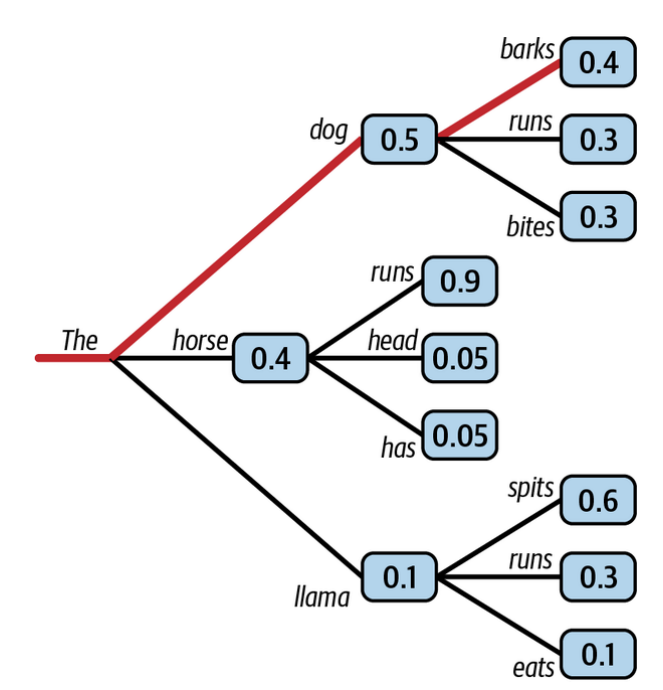

<div style="border-style:groove;border-width:thin;padding:10px">

El beam search explora múltiples continuaciones posibles de la secuencia y devuelve la continuación más probable.

</div>

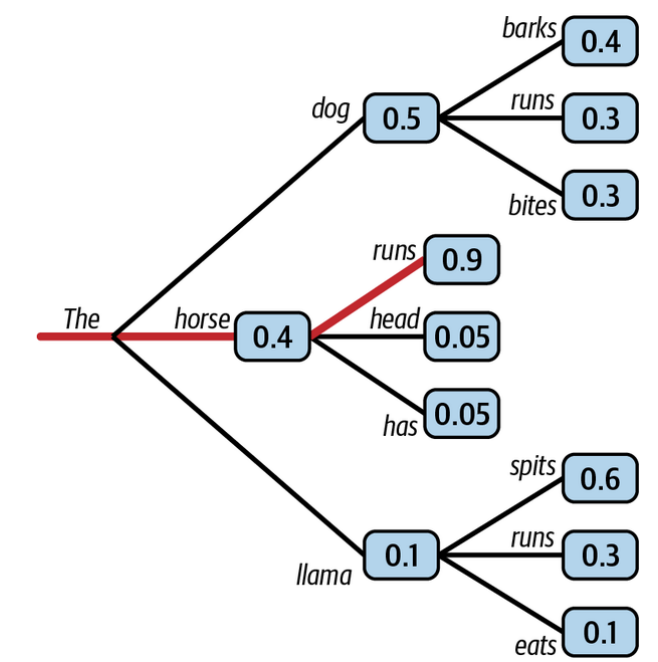

In [8]:
beam_output = model.generate(
input_ids,
num_beams=5,
max_new_tokens=30,
)
print(tokenizer.decode(beam_output[0]))

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It was a dark and stormy night. The wind was howling, and the rain was pouring down. The sky was dark and gloomy, and the air was filled with the


<div style="border-style:groove;border-width:thin;padding:10px">

Cuando num_beams es mayor que 1, el método generate() activa automáticamente beam search en lugar de greedy decoding. El valor indica cuántas "hipótesis" paralelas mantiene el modelo durante la generación — en este caso, 5.
Si usaras num_beams=1 (que es el valor por defecto), el comportamiento sería greedy decoding, ya que solo se considera un candidato a la vez, que es precisamente el token más probable en cada paso.

</div>

<div style="border-style:groove;border-width:thin;padding:10px">

Tenemos un parámetro que nos permite repetir menos tokens:

</div>

In [9]:
beam_output = model.generate(
input_ids,
num_beams=5,
repetition_penalty=2.0,
max_new_tokens=38,
)
print(tokenizer.decode(beam_output[0]))

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It was a dark and stormy night. The wind howled, the rain pounded, and the thunder rumbled through the air. It was just after 10:00 p.m., and I was sitting in


<div style="border-style:groove;border-width:thin;padding:10px">

¿Que estrategia usamos? Depende. El beam search funciona bien cuando la longitud del texto es predecible, como en resumen o traducción, pero no en generación abierta, donde tiende a la repetición. Además, es más lento que greedy search al tener que procesar varios beams simultáneamente.

</div>

<div style="border-style:groove;border-width:thin;padding:10px">

Curiosamente, el lenguaje humano de calidad no sigue una distribución de alta probabilidad: tiende a ser más impredecible, evitando lo obvio. Para imitar esto se propone el método llamado nucleus sampling.

</div>

<div style="border-style:groove;border-width:thin;padding:10px">

Con sampling, el siguiente token se elige muestreando de la distribución de probabilidad, por lo que no es un proceso determinista. Por ejemplo, si "night" tiene un 60% y "apple" un 5%, existe esa posibilidad de elegir "apple" aunque lleve a texto sin sentido. Esto evita la repetición y produce generaciones más diversas. En transformers se activa con el parámetro do_sample.
</div>

In [10]:
from transformers import set_seed
# Setting the seed ensures we get the same results every time we run this code
set_seed(70)
sampling_output = model.generate(
input_ids,
do_sample=True,
max_new_tokens=34,
top_k=0, # We'll come back to this parameter
)
print(tokenizer.decode(sampling_output[0]))

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It was a dark and stormy night, the temperature in the neighborhood was a hundred and eighty degrees.
Our News Minute Tonight shared our voice, on What It Takes to Win Heartbreak on Newscast


<div style="border-style:groove;border-width:thin;padding:10px">

#### Temperatura

- **Temperatura alta (> 1)**: más aleatoriedad, texto más creativo pero menos coherente
- **Temperatura baja (< 1)**: más determinismo, texto más repetitivo
- **Temperatura = 0**: equivalente a greedy decoding

</div>

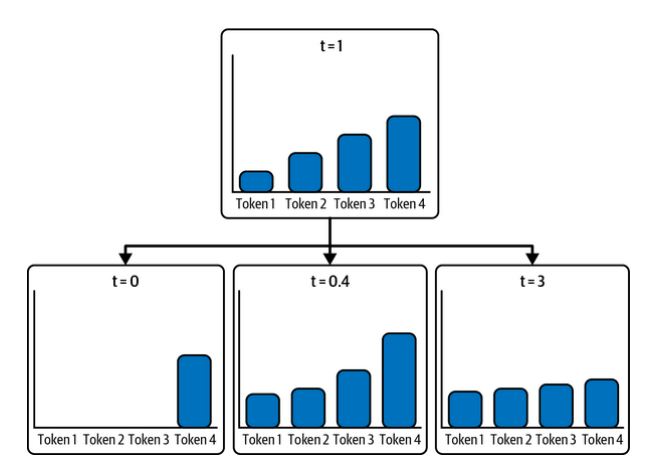

In [11]:
sampling_output = model.generate(
input_ids,
do_sample=True,
temperature=0.4,
max_new_tokens=40,
top_k=0,
)
print(tokenizer.decode(sampling_output[0]))

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It was a dark and stormy night in the house, when we were all gathered around the fire. We were all looking forward to the night we were going to be together. I was sitting on the couch, watching the movie,


<div style="border-style:groove;border-width:thin;padding:10px">

El Top-K sampling considera únicamente los K tokens más probables y redistribuye sus probabilidades. El problema es que el número de candidatos relevantes puede variar mucho: con top_k=5, algunas distribuciones incluirán tokens de probabilidad muy baja mientras que otras solo tendrán tokens de alta probabilidad.

</div>

<div style="border-style:groove;border-width:thin;padding:10px">

El Top-p sampling (o nucleus sampling) no fija un número de tokens, sino que selecciona los tokens más probables cuya probabilidad acumulada supere un umbral dado. Con top_p=0.94, se mantienen los tokens que sumen al menos el 94% de probabilidad, se redistribuyen y se muestrea normalmente.

</div>

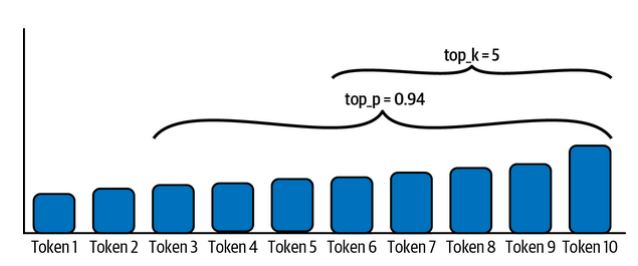

In [12]:
sampling_output = model.generate(
input_ids,
do_sample=True,
max_new_tokens=40,
top_p=0.94,
top_k=0,
)
print(tokenizer.decode(sampling_output[0]))

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It was a dark and stormy night. Scientists poured all night into analyzing a stormy sky. A storm grew up out of the southwest in the big circle of storm cells.
On Monday, at 10.40 pm


#### EJERCICIO:

<div style="border-style:groove;border-width:thin;padding:10px">

Experimenta con diferentes valores de parámetros. ¿Cómo afecta aumentar el número de beams a la calidad de la generación? ¿Qué ocurre si reduces o aumentas el valor de top_p? Usa un texto diferente y más complicado para el modelo. Que tenga posibilidades de alucinar.

</div>

In [15]:
#Tu código
prompt = "En un futuro donde la inteligencia artificial controla todos los sistemas críticos, un error inesperado provoca"

input_ids = tokenizer(prompt, return_tensors="pt").input_ids

# Beam search con diferentes valores
beam_output_2 = model.generate(input_ids, max_new_tokens=50, num_beams=2)
beam_output_5 = model.generate(input_ids, max_new_tokens=50, num_beams=5)

print("Beams = 2:\n", tokenizer.decode(beam_output_2[0]), "\n")
print("Beams = 5:\n", tokenizer.decode(beam_output_5[0]), "\n")

# Sampling con distintos top_p
sampling_low = model.generate(input_ids, do_sample=True, top_p=0.5, max_new_tokens=50)
sampling_high = model.generate(input_ids, do_sample=True, top_p=0.95, max_new_tokens=50)

print("top_p = 0.5:\n", tokenizer.decode(sampling_low[0]), "\n")
print("top_p = 0.95:\n", tokenizer.decode(sampling_high[0]))

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Beams = 2:
 En un futuro donde la inteligencia artificial controla todos los sistemas críticos, un error inesperado provoca un impacto devastador en la vida de miles de personas. Por lo tanto, es crucial que las empresas se aseguren de que sus sistemas de control de riesgo sean eficientes y seguros. Para ello, es importante que las empresas 

Beams = 5:
 En un futuro donde la inteligencia artificial controla todos los sistemas críticos, un error inesperado provoca la muerte de miles de personas. ¿Cuál es la probabilidad de que se produzca un error inesperado en el futuro?

Para resolver este problema, necesitamos determinar la probabilidad de que un error inesperado 



[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


top_p = 0.5:
 En un futuro donde la inteligencia artificial controla todos los sistemas críticos, un error inesperado provoca un caos en la vida cotidiana. La inteligencia artificial se ha convertido en una herramienta clave para reducir el riesgo de errores y mejorar la eficiencia en diversas áreas. Por ejemplo, la inteligencia artificial puede ayud 

top_p = 0.95:
 En un futuro donde la inteligencia artificial controla todos los sistemas críticos, un error inesperado provoca una explosión de rara. ¿Cuántas raras son? Una vez detectado, un error inesperado provoca un error inesperado. Sin embargo, el número exacto de raras es tan desconcertante como la


#### EJERCICIO:

<div style="border-style:groove;border-width:thin;padding:10px">

Investiga que parámetros por defecto usan gemmini o chatgpt y haz pruebas usando sus mismos parámetros:

</div>

In [16]:
#Tu código
prompt = "Explica cómo funciona un agujero negro de forma sencilla pero científicamente correcta."

input_ids = tokenizer(prompt, return_tensors="pt").input_ids

chatgpt_like = model.generate(
    input_ids,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    max_new_tokens=100
)

print(tokenizer.decode(chatgpt_like[0]))

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Explica cómo funciona un agujero negro de forma sencilla pero científicamente correcta. Un agujero negro es un dispositivo que utiliza la radiación de la luz para generar luz verde. Esto ayuda a mantener la visión de la luz en un lugar donde la luz se dispersa a través de la atmósfera, lo que se puede ver en el cielo. Los agujeros negros se utilizan para detectar la luz de la atmósfera, para detectar la luz del sol, para identificar la luz de la luna y para detect
